# AI 4200 Project 1: Residual MLPs on MNIST, CIFAR-10, and ImageNet 32×32

This notebook is the **test harness** for Project 1. It does three things:

1. Installs your package from GitHub.
2. Downloads the three datasets. It saves a copy in `data/`, so later runs load from disk instead of downloading again.
3. Calls your `train()` and `predict()` on each task and reports test accuracy.

Develop your model in your own environment. Use this notebook to check that your submission runs end to end, exactly as it will when it is graded.

## The tasks

| Task | Images | Classes | Train | Test |
|---|---|---|---|---|
| `mnist` | 28×28 grayscale digits | 10 | 60,000 | 10,000 |
| `cifar10` | 32×32 color objects | 10 | 50,000 | 10,000 |
| `imagenet32` | 32×32 color, ImageNet downsampled | 1000 | 1,281,167 | 50,000 (the official validation set) |

Every task uses the same format:

- **Images:** `X` is a `uint8` NumPy array with shape `(N, channels, height, width)` and values from 0 to 255.
- **Labels:** `y` is an `int64` array of class indices.

## The rules

**Allowed:**

- **Network pieces:** linear layers, activations, normalization layers, and residual connections, at any depth and width.
- **Training choices:** any loss, optimizer, learning-rate schedule, regularizer, or initialization.
- **Data handling:** augmentation, test-time augmentation, and patch-style tricks or mixing across positions, as long as you can explain them.

**Not allowed:**

- No convolutions, recurrent layers, or other new layer types.
- No ensembles.
- No pretrained weights and no distillation. The model must be trained from the data directly.
- No data beyond what each benchmark provides.
- No loading saved weights. `train()` must build and train the model from scratch.

**Required interface.** Your package must provide these two functions:

```python
model = train(task, X_train, y_train, seed=0, device="cuda")  # build and train from scratch
probs = predict(model, X_test)                                # (N, num_classes) probabilities
```

See the README in the baseline repository for the full assignment.

## 1. Setup

**Your submission.** These four lines are the only ones you need to change. As shipped, they test the instructor's baseline and post its results as `baseline`. Point them at your own repository and pick your own nickname before you run.

In [ ]:
# ---- Your submission: change these four lines -----------------------------

# Your GitHub repository, in the form pip installs from. This example is the
# instructor's baseline: https://github.com/JesseTNRoberts/AI4200-imagenet32x32-baseline-model
PACKAGE_URL = "git+https://github.com/cchamb-gh/AI4200-imagenet32x32-baseline-model.git"

# The name you import your package by (the folder inside src/).
IMPORT_NAME = "residual_mlp_baseline"

# Your nickname on the unofficial leaderboard (not your real name).
# Set it to "" to keep your results off the leaderboard.
LEADERBOARD_ALIAS = "memory leak"

# Your section: "4000" or "5000".
SECTION = "5000"

**Harness settings.** You normally leave these alone.

In [ ]:
import os

# Where the datasets are saved. Keep this folder between runs to skip downloading.
DATA_DIR = "data"

# Which tasks to run. Remove some while testing to save time.
TASKS_TO_RUN = ["mnist", "cifar10", "imagenet32"]
#TASKS_TO_RUN = ["mnist"]


SEED = 0

# Every finished task adds one row to this file.
RESULTS_FILE = "results.csv"

# The unofficial leaderboard's Google Form.
LEADERBOARD_FORM = "https://docs.google.com/forms/d/e/1FAIpQLScZjEdbLFtn1CNvsfwYEbM4YGRxdOU5cyJ7RANM7MrxT0a4oA/viewform?usp=dialog"
BASELINE_URL = "git+https://github.com/JesseTNRoberts/AI4200-imagenet32x32-baseline-model.git"

# The instructor's grading script runs this notebook for every student and
# sets these through environment variables instead of editing the cells.
PACKAGE_URL = os.environ.get("HARNESS_PACKAGE_URL", PACKAGE_URL)
IMPORT_NAME = os.environ.get("HARNESS_IMPORT_NAME", IMPORT_NAME)
LEADERBOARD_ALIAS = os.environ.get("HARNESS_LEADERBOARD_ALIAS", LEADERBOARD_ALIAS)
DATA_DIR = os.environ.get("HARNESS_DATA_DIR", DATA_DIR)
RESULTS_FILE = os.environ.get("HARNESS_RESULTS_FILE", RESULTS_FILE)
TASKS_TO_RUN = os.environ.get("HARNESS_TASKS", ",".join(TASKS_TO_RUN)).split(",")

In [3]:
# Install the package straight from GitHub.
# --force-reinstall always grabs your latest commit, even if the version
# number did not change. --no-deps leaves the installed PyTorch (and its
# GPU support) alone.
%pip install -q --force-reinstall --no-deps {PACKAGE_URL}

# The Hugging Face `datasets` library downloads the benchmarks.
%pip install -q datasets


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import csv
import importlib
import time
import zipfile

import numpy as np
import torch

student = importlib.import_module(IMPORT_NAME)   # your package
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Testing", IMPORT_NAME, "on", DEVICE)

Testing residual_mlp_baseline on cuda


## 2. Get the datasets

All three datasets come from the Hugging Face Hub. The first run downloads each one and saves it as NumPy files in a folder under `DATA_DIR`, for example `data/cifar10/`. Later runs find that folder and skip the download.

ImageNet 32×32 is the large one: about 0.7 GB to download and about 4 GB on disk once saved. Converting it the first time takes several minutes. The saved arrays are memory-mapped, so they are read from disk as needed instead of filling your RAM. ImageNet is released for non-commercial research and education only.

In [5]:
# For each task: Hugging Face dataset name, image column, train split, test split.
SOURCES = {
    "mnist":      ("ylecun/mnist",                     "image", "train", "test"),
    "cifar10":    ("uoft-cs/cifar10",                  "img",   "train", "test"),
    "imagenet32": ("benjamin-paine/imagenet-1k-32x32", "image", "train", "validation"),
}
NUM_CLASSES = {"mnist": 10, "cifar10": 10, "imagenet32": 1000}


def save_split(split, image_column, mode, folder, name):
    """Write one Hugging Face split to X_<name>.npy (N, C, H, W) and y_<name>.npy.

    The images are written straight into a file on disk, 10,000 at a time, so
    even ImageNet (about 4 GB) never has to fit in memory all at once.
    """
    n = len(split)
    height, width = np.asarray(split[0][image_column]).shape[:2]
    channels = 1 if mode == "L" else 3
    X = np.lib.format.open_memmap(os.path.join(folder, f"X_{name}.npy"), mode="w+",
                                  dtype=np.uint8, shape=(n, channels, height, width))
    y = np.empty(n, dtype=np.int64)
    for start in range(0, n, 10_000):
        chunk = split[start:start + 10_000]
        # mode is "L" (grayscale) or "RGB"; convert() fixes any odd image formats.
        images = np.stack([np.asarray(img.convert(mode)) for img in chunk[image_column]])
        stop = start + len(images)
        X[start:stop] = images[:, None] if mode == "L" else images.transpose(0, 3, 1, 2)
        y[start:stop] = chunk["label"]
        print(f"  {name}: {stop:,} / {n:,} images", end="\r")
    print()
    X.flush()
    np.save(os.path.join(folder, f"y_{name}.npy"), y)


def load_task(task):
    """Return X_train, y_train, X_test, y_test, downloading only if there is no saved copy.

    The arrays are memory-mapped: they are read from disk as they are used
    instead of all being loaded into RAM up front.
    """
    folder = os.path.join(DATA_DIR, task)
    old_file = os.path.join(DATA_DIR, f"{task}.npz")   # saved by an earlier version of this notebook

    if not os.path.isdir(folder) and os.path.exists(old_file):
        # Unpack the earlier single-file copy into the folder format; no download needed.
        print(f"{task}: unpacking {old_file} (one time only; you can delete it afterwards)")
        temp_folder = folder + ".partial"
        os.makedirs(temp_folder, exist_ok=True)
        # An .npz file is a zip of .npy files, so extracting it streams them to disk
        # without loading the arrays into memory.
        with zipfile.ZipFile(old_file) as old:
            old.extractall(temp_folder)
        os.replace(temp_folder, folder)

    if not os.path.isdir(folder):                    # no saved copy yet: download it
        from datasets import load_dataset
        name, image_column, train_split, test_split = SOURCES[task]
        mode = "L" if task == "mnist" else "RGB"
        print(f"{task}: getting {name} from Hugging Face (first run only; reuses its download cache if present)")

        # Write into a temporary folder, then rename it. An interrupted run then
        # never leaves a half-written folder that looks like a finished one.
        temp_folder = folder + ".partial"
        os.makedirs(temp_folder, exist_ok=True)
        save_split(load_dataset(name, split=train_split), image_column, mode, temp_folder, "train")
        save_split(load_dataset(name, split=test_split), image_column, mode, temp_folder, "test")
        os.replace(temp_folder, folder)

    # mmap_mode="c" (copy-on-write): read from disk on demand, and any changes
    # your code makes to the arrays stay in memory and never touch the files.
    return tuple(np.load(os.path.join(folder, f"{part}.npy"), mmap_mode="c")
                 for part in ["X_train", "y_train", "X_test", "y_test"])

In [6]:
# Download (or load) every task once and check what we got.
for task in TASKS_TO_RUN:
    X_train, y_train, X_test, y_test = load_task(task)
    print(f"{task:>10}: X_train {X_train.shape} {X_train.dtype}, X_test {X_test.shape}, "
          f"labels {y_train.min()}..{y_train.max()}")
    del X_train, y_train, X_test, y_test             # free memory before the next one

mnist: getting ylecun/mnist from Hugging Face (first run only; reuses its download cache if present)


README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

mnist/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.6MB            

mnist/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mnist/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.60MB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1281167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100000 [00:00<?, ? examples/s]

  train: 1,281,167 / 1,281,167 images
  test: 50,000 / 50,000 images
imagenet32: X_train (1281167, 3, 32, 32) uint8, X_test (50000, 3, 32, 32), labels 0..999


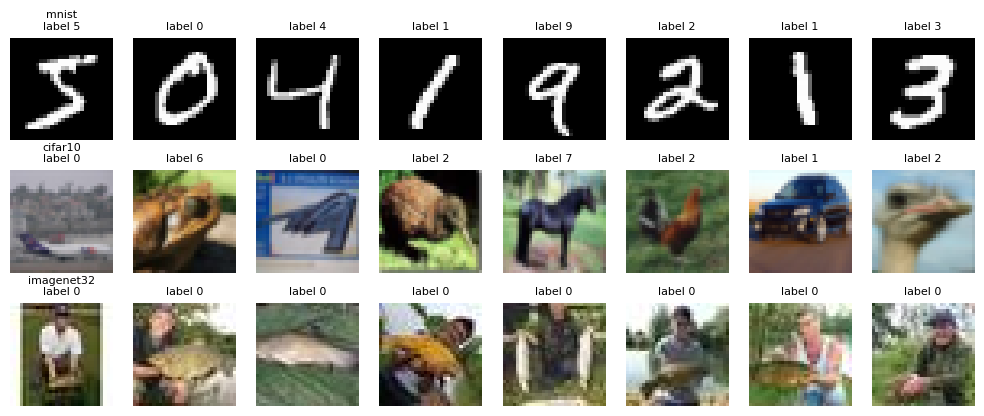

In [7]:
# A quick look at a few training images from each task.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(TASKS_TO_RUN), 8, figsize=(10, 1.4 * len(TASKS_TO_RUN)), squeeze=False)
for row, task in enumerate(TASKS_TO_RUN):
    X_train, y_train, _, _ = load_task(task)
    for col in range(8):
        img = X_train[col].transpose(1, 2, 0)          # (C, H, W) -> (H, W, C) for plotting
        axes[row, col].imshow(img.squeeze(), cmap="gray" if img.shape[2] == 1 else None)
        axes[row, col].set_title(f"{task}\nlabel {y_train[col]}" if col == 0 else f"label {y_train[col]}", fontsize=8)
        axes[row, col].axis("off")
    del X_train, y_train
plt.tight_layout()
plt.show()

## 3. Train and evaluate

For each task, this section:

1. Calls `train()` on the training set.
2. Calls `predict()` on the test set.
3. Checks the format of the output.
4. Computes test accuracy.

Accuracy is computed here, by the notebook, not by your code. Each result is also added to `results.csv` as soon as that task finishes.

**Unofficial leaderboard.** If `LEADERBOARD_ALIAS` is set in Setup, each result is also posted to the class's live leaderboard under that nickname. It is just for fun: the official ranking for extra credit comes from the instructor's own run of your final commit.

**Long runs on a cluster.** If your browser loses its connection to Jupyter, training keeps going but the printed output stops appearing on the page. `results.csv` still records every finished task. To avoid the problem entirely, run the whole notebook from a terminal instead of the browser:

```bash
jupyter nbconvert --to notebook --execute project1_harness.ipynb \
    --output harness_run.ipynb --ExecutePreprocessor.timeout=-1
```

The finished notebook, with all its output, is saved as `harness_run.ipynb`.

In [8]:
import json
import re
import urllib.parse
import urllib.request

LEADERBOARD_QUESTIONS = ["alias", "section", "task", "accuracy", "minute", "repo"]
_form_fields = None   # the form's field names, looked up once


def find_form_fields():
    """Return the form's field names (entry.NNN), one per question, in the order above."""
    address, _, query = LEADERBOARD_FORM.partition("?")
    entries = [key for key, _ in urllib.parse.parse_qsl(query) if key.startswith("entry.")]
    if len(entries) >= len(LEADERBOARD_QUESTIONS):           # a pre-filled link lists them
        return entries[:len(LEADERBOARD_QUESTIONS)]
    # Otherwise read them from the form page itself.
    page = urllib.request.urlopen(address, timeout=20).read().decode("utf-8")
    data = json.loads(re.search(r"FB_PUBLIC_LOAD_DATA_ = (.*?);\s*</script>", page, re.S).group(1))
    questions = [(q[1] or "", f"entry.{q[4][0][0]}") for q in data[1][1] if q[4]]
    fields = []
    for position, keyword in enumerate(LEADERBOARD_QUESTIONS):   # match by title, else by position
        match = [entry for title, entry in questions if keyword in title.lower()]
        fields.append(match[0] if match else questions[position][1])
    return fields


def post_to_leaderboard(task, accuracy, train_minutes):
    """Send one result to the unofficial leaderboard. A failure only prints a warning."""
    global _form_fields
    alias = LEADERBOARD_ALIAS.strip()
    if not alias or not LEADERBOARD_FORM:
        return
    if alias.lower() == "baseline" and PACKAGE_URL != BASELINE_URL:
        print("  not posted: set LEADERBOARD_ALIAS to your own nickname to join the leaderboard")
        return
    answers = [alias, SECTION, task, f"{accuracy:.4f}", f"{train_minutes:.1f}", PACKAGE_URL]
    try:
        if _form_fields is None:
            _form_fields = find_form_fields()
        address = LEADERBOARD_FORM.partition("?")[0].replace("/viewform", "/formResponse")
        data = urllib.parse.urlencode(dict(zip(_form_fields, answers))).encode()
        urllib.request.urlopen(address, data=data, timeout=20)
        print(f"  posted to the leaderboard as {alias}")
    except Exception as error:
        print(f"  could not post to the leaderboard ({error}); the result is still in {RESULTS_FILE}")

In [9]:
results = []

for task in TASKS_TO_RUN:
    print(f"\n===== {task} =====")
    X_train, y_train, X_test, y_test = load_task(task)

    # Train from scratch.
    start = time.time()
    model = student.train(task, X_train, y_train, seed=SEED, device=DEVICE)
    train_minutes = (time.time() - start) / 60

    # Predict on the held-out test set.
    probs = torch.as_tensor(student.predict(model, X_test)).float().cpu()

    # Check that predict() returned one probability row per test image.
    assert probs.shape == (len(y_test), NUM_CLASSES[task]), f"predict() returned shape {tuple(probs.shape)}"
    assert torch.allclose(probs.sum(dim=1), torch.ones(len(probs)), atol=1e-3), "rows of predict() must sum to 1"

    accuracy = (probs.argmax(dim=1).numpy() == y_test).mean()
    results.append((task, accuracy, train_minutes))
    print(f"{task}: test accuracy {accuracy:.2%}  (training took {train_minutes:.1f} min)")

    # Save the result to a file right away, in case the browser stops showing output.
    new_file = not os.path.exists(RESULTS_FILE)
    with open(RESULTS_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        if new_file:
            writer.writerow(["time", "package_url", "import_name", "task", "accuracy", "train_minutes", "seed"])
        writer.writerow([time.strftime("%Y-%m-%d %H:%M"), PACKAGE_URL, IMPORT_NAME, task,
                         f"{accuracy:.4f}", f"{train_minutes:.1f}", SEED])
    post_to_leaderboard(task, accuracy, train_minutes)

    del model, X_train, y_train, X_test, y_test, probs   # free memory before the next task
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


===== mnist =====
epoch 1: train loss 0.6411
epoch 2: train loss 0.2372
epoch 3: train loss 0.1716
epoch 4: train loss 0.1305
epoch 5: train loss 0.1086
epoch 6: train loss 0.1477
epoch 7: train loss 0.0764
epoch 8: train loss 0.0650
epoch 9: train loss 0.0634
epoch 10: train loss 0.1993
mnist: test accuracy 95.06%  (training took 0.6 min)
  posted to the leaderboard as baseline

===== cifar10 =====
epoch 1: train loss 1.8069
epoch 2: train loss 1.6184
epoch 3: train loss 1.5190
epoch 4: train loss 1.4431
epoch 5: train loss 1.3901
epoch 6: train loss 1.3284
epoch 7: train loss 1.2933
epoch 8: train loss 1.2438
epoch 9: train loss 1.2025
epoch 10: train loss 1.1663
epoch 11: train loss 1.1287
epoch 12: train loss 1.0950
epoch 13: train loss 1.0569
epoch 14: train loss 1.0240
epoch 15: train loss 0.9865
epoch 16: train loss 0.9567
epoch 17: train loss 0.9238
epoch 18: train loss 0.8885
epoch 19: train loss 0.8488
epoch 20: train loss 0.8130
epoch 21: train loss 0.7905
epoch 22: train l

## 4. Results

In [10]:
print(f"{'task':>10} | {'test accuracy':>13} | {'train time':>10}")
print("-" * 41)
for task, accuracy, minutes in results:
    print(f"{task:>10} | {accuracy:>13.2%} | {minutes:>6.1f} min")

      task | test accuracy | train time
-----------------------------------------
     mnist |        95.06% |    0.6 min
   cifar10 |        48.61% |    1.3 min
imagenet32 |         6.77% |   12.4 min
